In [9]:
import wfdb
import numpy as np
import neurokit2 as nk
import scipy.signal as sp
import matplotlib.pyplot as plt
import time
import os

In [7]:
# -------------------------------------------------------------
# Define your local dataset path
# -------------------------------------------------------------
base_path = "../../../../local3/sswee/data/shdbaf/physionet.org/files/shdb-af/1.0.1"

# -------------------------------------------------------------
# Time the ECG loading process
# -------------------------------------------------------------
start_time = time.time()

record = wfdb.rdrecord(f"{base_path}/001")
signal = record.p_signal[:, 0]
fs = record.fs

end_time = time.time()
load_time = end_time - start_time

# -------------------------------------------------------------
# Print summary information
# -------------------------------------------------------------
print(f"Sampling rate: {fs} Hz")
print(f"Signal length: {len(signal)} samples")
print(f"ECG loaded in {load_time:.3f} seconds")

Sampling rate: 200 Hz
Signal length: 17220000 samples
ECG loaded in 19.900 seconds


Bandpass filtering took 17.013 seconds
Baseline correction took 1.027 seconds
Z-score normalization took 0.092 seconds


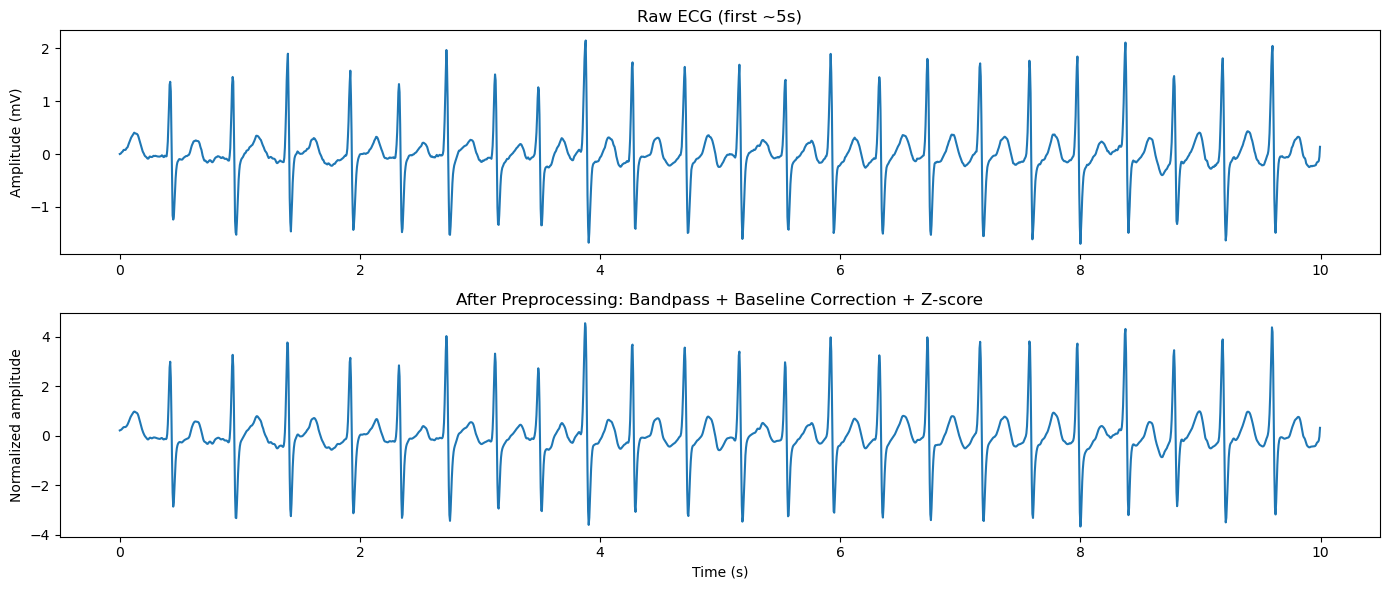

In [8]:
# -------------------------------------------------------------
# Bandpass filter (0.5–40 Hz)
# -------------------------------------------------------------
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40, order=4):
    nyquist = 0.5 * fs
    b, a = sp.butter(order, [lowcut / nyquist, highcut / nyquist], btype='band')
    return sp.filtfilt(b, a, signal)

start_time = time.time()
filtered = bandpass_filter(signal, fs)
print(f"Bandpass filtering took {time.time() - start_time:.3f} seconds")

# -------------------------------------------------------------
# Baseline correction (median filter)
# -------------------------------------------------------------
def baseline_correction(signal, fs, window_sec=0.8):
    baseline = sp.medfilt(signal, kernel_size=int(window_sec*fs//2*2+1))
    return signal - baseline

start_time = time.time()
baseline_corrected = baseline_correction(filtered, fs)
print(f"Baseline correction took {time.time() - start_time:.3f} seconds")

# -------------------------------------------------------------
# Z-score normalization
# -------------------------------------------------------------
start_time = time.time()
normalized = (baseline_corrected - np.mean(baseline_corrected)) / np.std(baseline_corrected)
print(f"Z-score normalization took {time.time() - start_time:.3f} seconds")

# -------------------------------------------------------------
# Plot first few seconds for verification
# -------------------------------------------------------------
t = np.arange(len(signal)) / fs
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(t[:2000], signal[:2000])
plt.title("Raw ECG (first ~5s)")
plt.ylabel("Amplitude (mV)")

plt.subplot(2, 1, 2)
plt.plot(t[:2000], normalized[:2000])
plt.title("After Preprocessing: Bandpass + Baseline Correction + Z-score")
plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")
plt.tight_layout()
plt.show()


In [11]:
# -------------------------------------------------------------
# Define output directory (local preprocessed folder)
# -------------------------------------------------------------
save_dir = "../../../../local3/sswee/data/shdbaf/physionet.org/files/shdb-af/preprocessed"
os.makedirs(save_dir, exist_ok=True)

# Record name (e.g., '001' to match original SHDB-AF file)
record_name = "001"

# Construct save path
save_path = os.path.join(save_dir, f"{record_name}_preprocessed.npz")

# -------------------------------------------------------------
# Save preprocessed data with timing
# -------------------------------------------------------------
start_time = time.time()

normalized32 = normalized.astype(np.float32)

np.savez_compressed(
    save_path,
    signal=normalized32,
    fs=fs,
    record_name=record_name,
    n_samples=len(normalized32)
)

end_time = time.time()
save_time = end_time - start_time

# -------------------------------------------------------------
# Print summary
# -------------------------------------------------------------
file_size_mb = os.path.getsize(save_path) / 1024 / 1024
print(f"Saved preprocessed ECG to: {save_path}")
print(f"File size: {file_size_mb:.2f} MB")
print(f"Saving took {save_time:.3f} seconds")


Saved preprocessed ECG to: ../../../../local3/sswee/data/shdbaf/physionet.org/files/shdb-af/preprocessed/001_preprocessed.npz
File size: 60.96 MB
Saving took 3.143 seconds
